# Instructor Effectiveness Modeling (EdTech)

 "metadata": {
    "kernelspec": {
     "display_name": "Python 3.14",
     "language": "python",
     "name": "python3"
    },


## 1. Setup and Load

We set one random seed, use relative paths, select the requested CSV deterministically, and inspect its structure before analysis. No synthetic or fallback data is allowed.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import PartialDependenceDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_recall_fscore_support
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
RANDOM_STATE = 42
DATA_DIR = Path("data")
requested_path = DATA_DIR / "instructor_data.csv"
csv_paths = sorted(DATA_DIR.glob("*.csv"))
DATA_PATH = requested_path if requested_path.exists() else (csv_paths[0] if len(csv_paths) == 1 else None)
if DATA_PATH is None:
    raise FileNotFoundError("No real CSV found. Put the dataset in ./data/instructor_data.csv or make ./data/ contain one CSV.")

df = pd.read_csv(DATA_PATH)
required = ["batch_id", "instructor_id", "course_id", "completion_rate", "dropout_rate", "avg_score_improvement", "avg_quiz_score", "avg_watch_time", "assignment_submission_rate", "forum_activity_rate", "avg_feedback_score", "feedback_response_rate"]
column_map = {}
missing_required = sorted(set(required) - set(df.columns))
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}. Add an explicit column_map before loading.")
print(f"DATA_PATH: {DATA_PATH}")
print("Shape:", df.shape)
print("Columns:", list(df.columns))
print("Dtypes:\n", df.dtypes)
print("Head:\n", df.head())
print("Missing counts:\n", df.isna().sum())
assert set(required).issubset(df.columns)


DATA_PATH: data\instructor_data.csv
Shape: (2000, 12)
Columns: ['batch_id', 'instructor_id', 'course_id', 'completion_rate', 'avg_score_improvement', 'avg_quiz_score', 'dropout_rate', 'avg_watch_time', 'assignment_submission_rate', 'forum_activity_rate', 'avg_feedback_score', 'feedback_response_rate']
Dtypes:
 batch_id                          str
instructor_id                     str
course_id                         str
completion_rate               float64
avg_score_improvement         float64
avg_quiz_score                float64
dropout_rate                  float64
avg_watch_time                float64
assignment_submission_rate    float64
forum_activity_rate           float64
avg_feedback_score            float64
feedback_response_rate        float64
dtype: object
Head:
   batch_id instructor_id course_id  completion_rate  avg_score_improvement  \
0   B_1861         I_044      C_01         0.300000              14.225955   
1   B_0354         I_119      C_06         0.657220    

## 2. EDA: Data Quality and Distributions

These checks use only the real CSV. The plots are interpreted in the following Early Observations markdown cell, including clipping, outcome-engagement associations, redundancy, feedback response bias, and instructor-level clustering.


### Early Observations and Plot Reading

The real data contain 625 completion/dropout mismatches beyond +/- 0.05, including floor/cap values at completion `0.30` and dropout `0.70`. The completion/dropout correlation is printed above; it shows why both variables should not be interpreted as independent evidence.

The box plot highlights metric ranges and possible clipping; the histogram shows whether feedback is concentrated near the ceiling; the batches-per-instructor histogram shows experience coverage. The feedback scatter checks response-rate bias, while the heatmap and outcome-vs-engagement table show association structure. The ICC is descriptive evidence of instructor-level clustering, not causal proof.


## 3. Course-Adjusted Effectiveness Score

Each outcome and feedback metric is z-scored within course_id. The score weights learning outcomes at 0.60, reliability-weighted feedback at 0.25, and consistency at 0.15. Empirical-Bayes shrinkage pulls small-sample instructor means toward the global mean before tercile assignment.


Duplicate rows: 0
Out-of-range rate counts: {'completion_rate': 0, 'dropout_rate': 0, 'avg_watch_time': 0, 'assignment_submission_rate': 0, 'forum_activity_rate': 0, 'feedback_response_rate': 0}
Out-of-range feedback count: 0
Completion + dropout summary:
 count    2000.000000
mean        0.997692
std         0.049259
min         0.828710
25%         0.965302
50%         0.999425
75%         1.029358
max         1.160438
dtype: float64
Rows outside +/- 0.05 consistency tolerance: 625
Completion == 0.30: 77
Dropout == 0.70: 72
Ceiling/floor counts:
 {'completion_rate': {'at_min': 77, 'at_max': 32}, 'dropout_rate': {'at_min': 23, 'at_max': 72}, 'avg_watch_time': {'at_min': 1, 'at_max': 149}, 'assignment_submission_rate': {'at_min': 1, 'at_max': 125}, 'forum_activity_rate': {'at_min': 14, 'at_max': 1}, 'feedback_response_rate': {'at_min': 1, 'at_max': 94}, 'avg_feedback_score': {'at_min': 1, 'at_max': 67}}
Exact feedback 5.0: 67
Exact watch time 1.0: 149
Completion/dropout correlation: -0

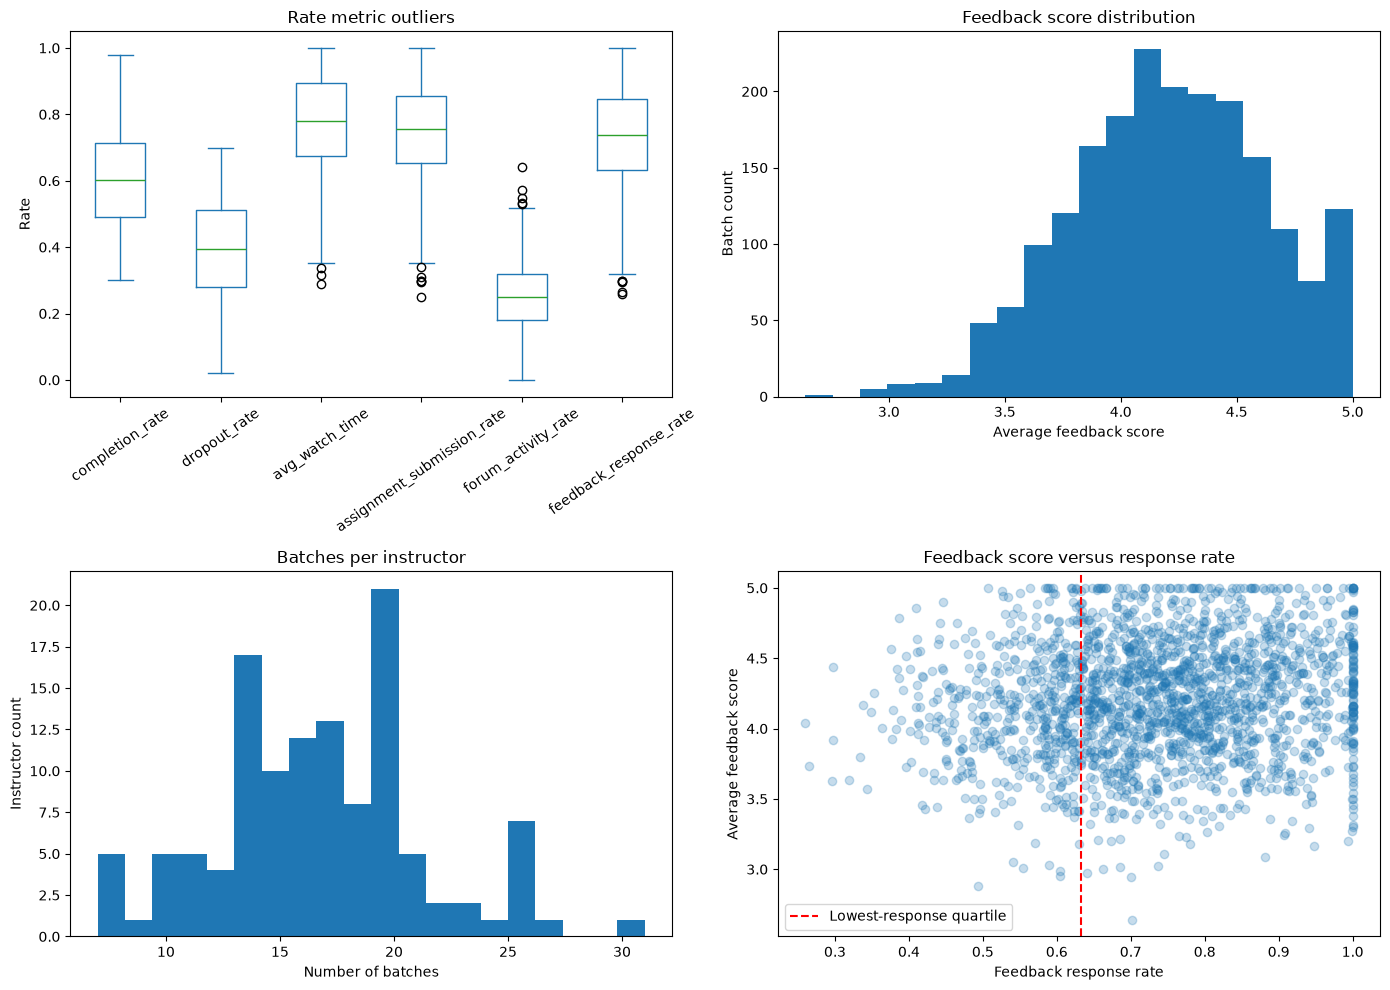

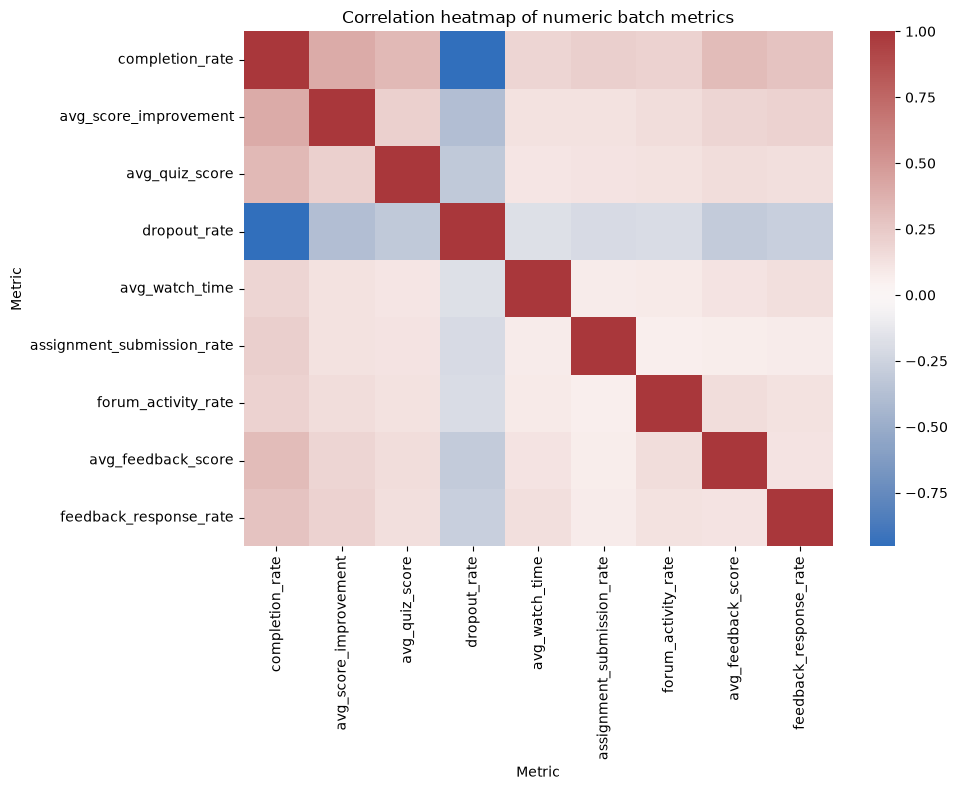

In [2]:
rate_cols = ["completion_rate", "dropout_rate", "avg_watch_time", "assignment_submission_rate", "forum_activity_rate", "feedback_response_rate"]
outcome_cols = ["completion_rate", "dropout_rate", "avg_score_improvement", "avg_quiz_score", "avg_feedback_score"]
print("Duplicate rows:", int(df.duplicated().sum()))
range_checks = {column: int(((df[column] < 0) | (df[column] > 1)).sum()) for column in rate_cols}
feedback_check = int(((df["avg_feedback_score"] < 1) | (df["avg_feedback_score"] > 5)).sum())
consistency = df["completion_rate"] + df["dropout_rate"]
print("Out-of-range rate counts:", range_checks)
print("Out-of-range feedback count:", feedback_check)
print("Completion + dropout summary:\n", consistency.describe())
print("Rows outside +/- 0.05 consistency tolerance:", int((consistency.sub(1).abs() > 0.05).sum()))
print("Completion == 0.30:", int((df["completion_rate"] == 0.30).sum()))
print("Dropout == 0.70:", int((df["dropout_rate"] == 0.70).sum()))
ceiling_floor = {column: {"at_min": int((df[column] == df[column].min()).sum()), "at_max": int((df[column] == df[column].max()).sum())} for column in rate_cols + ["avg_feedback_score"]}
print("Ceiling/floor counts:\n", ceiling_floor)
print("Exact feedback 5.0:", int((df["avg_feedback_score"] == 5.0).sum()))
print("Exact watch time 1.0:", int((df["avg_watch_time"] == 1.0).sum()))
print("Completion/dropout correlation:", round(float(df[["completion_rate", "dropout_rate"]].corr().iloc[0, 1]), 4))
print("Outcome-vs-engagement correlations:\n", df[outcome_cols + ["avg_watch_time", "assignment_submission_rate", "forum_activity_rate"]].corr().loc[outcome_cols, ["avg_watch_time", "assignment_submission_rate", "forum_activity_rate"]].round(4))
instructor_means = df.groupby("instructor_id")["avg_score_improvement"].mean()
within_var = df.groupby("instructor_id")["avg_score_improvement"].var().mean()
between_var = instructor_means.var()
intraclass_correlation = between_var / (between_var + within_var)
print("Intraclass correlation for avg_score_improvement:", round(float(intraclass_correlation), 4))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
df[rate_cols].plot(kind="box", ax=axes[0, 0], rot=35, title="Rate metric outliers")
axes[0, 0].set_ylabel("Rate")
df["avg_feedback_score"].plot(kind="hist", bins=20, ax=axes[0, 1], title="Feedback score distribution", legend=False)
axes[0, 1].set_xlabel("Average feedback score")
axes[0, 1].set_ylabel("Batch count")
df.groupby("instructor_id")["batch_id"].nunique().plot(kind="hist", bins=20, ax=axes[1, 0], title="Batches per instructor")
axes[1, 0].set_xlabel("Number of batches")
axes[1, 0].set_ylabel("Instructor count")
low_response = df["feedback_response_rate"] <= df["feedback_response_rate"].quantile(0.25)
axes[1, 1].scatter(df["feedback_response_rate"], df["avg_feedback_score"], alpha=0.25)
axes[1, 1].axvline(df.loc[low_response, "feedback_response_rate"].max(), color="red", linestyle="--", label="Lowest-response quartile")
axes[1, 1].set(title="Feedback score versus response rate", xlabel="Feedback response rate", ylabel="Average feedback score")
axes[1, 1].legend()
plt.tight_layout()

plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), cmap="vlag", center=0)
plt.title("Correlation heatmap of numeric batch metrics")
plt.xlabel("Metric")
plt.ylabel("Metric")
plt.tight_layout()


In [3]:
metric_cols = ["completion_rate", "dropout_rate", "avg_score_improvement", "avg_quiz_score", "avg_feedback_score"]
df["positive_dropout"] = 1 - df["dropout_rate"]
score_parts = ["completion_rate", "positive_dropout", "avg_score_improvement", "avg_quiz_score"]
for column in metric_cols + ["positive_dropout"]:
    # Course normalization makes the score compare instructors within the same course.
    course_mean = df.groupby("course_id")[column].transform("mean")
    course_std = df.groupby("course_id")[column].transform("std").replace(0, np.nan)
    df[f"z_{column}"] = ((df[column] - course_mean) / course_std).fillna(0)

df["learning_outcomes"] = df[[f"z_{column}" for column in score_parts]].mean(axis=1)
# Low response downweights unusually positive feedback, while negative feedback is conservatively penalized.
response_floor = max(float(df["feedback_response_rate"].quantile(0.25)), 0.25)
feedback_z = df["z_avg_feedback_score"]
reliability = df["feedback_response_rate"].clip(lower=response_floor)
df["feedback_component"] = np.where(feedback_z >= 0, feedback_z * reliability, feedback_z / reliability)
negative_feedback = feedback_z < -1
feedback_response_corr = df.loc[negative_feedback, ["feedback_response_rate", "feedback_component"]].corr().iloc[0, 1]
print("Feedback response floor:", round(response_floor, 4))
print("Correlation(response_rate, feedback_component) for z_feedback < -1:", round(float(feedback_response_corr), 4))
df["consistency_component"] = 1 - df.groupby("instructor_id")["learning_outcomes"].transform("std").fillna(0).clip(upper=1)
df["effectiveness_score"] = 0.60 * df["learning_outcomes"] + 0.25 * df["feedback_component"] + 0.15 * df["consistency_component"]

instructor_scores = df.groupby("instructor_id")["effectiveness_score"].agg(raw_mean="mean", within_variance="var")
global_mean = df["effectiveness_score"].mean()
within_variance = instructor_scores["within_variance"].mean()
between_variance = instructor_scores["raw_mean"].var()
prior_strength = max(float(within_variance / between_variance), 0.1) if between_variance > 0 else 1.0
instructor_scores["n_batches"] = df.groupby("instructor_id")["batch_id"].nunique()
instructor_scores["shrink_weight"] = instructor_scores["n_batches"] / (instructor_scores["n_batches"] + prior_strength)
instructor_scores["shrunk_score"] = instructor_scores["shrink_weight"] * instructor_scores["raw_mean"] + (1 - instructor_scores["shrink_weight"]) * global_mean
raw_cuts = instructor_scores["raw_mean"].quantile([1/3, 2/3]).to_numpy()
shrunk_cuts = instructor_scores["shrunk_score"].quantile([1/3, 2/3]).to_numpy()
instructor_scores["raw_tier"] = pd.cut(instructor_scores["raw_mean"], bins=[-np.inf, *raw_cuts, np.inf], labels=["Low", "Medium", "High"], include_lowest=True)
instructor_scores["tier"] = pd.cut(instructor_scores["shrunk_score"], bins=[-np.inf, *shrunk_cuts, np.inf], labels=["Low", "Medium", "High"], include_lowest=True)
instructor_scores["low_confidence"] = instructor_scores["shrink_weight"] < 0.8
tier_changes = int((instructor_scores["raw_tier"].astype(str) != instructor_scores["tier"].astype(str)).sum())
final_instructor_means = df.groupby("instructor_id")["effectiveness_score"].mean()
final_within_variance = df.groupby("instructor_id")["effectiveness_score"].var().mean()
final_between_variance = final_instructor_means.var()
final_score_icc = final_between_variance / (final_between_variance + final_within_variance)
print("Global mean, within variance, between variance:", round(global_mean, 4), round(within_variance, 4), round(between_variance, 4))
print("Prior strength:", round(prior_strength, 4))
print("Minimum batches per instructor:", int(instructor_scores["n_batches"].min()))
print("Final score ICC:", round(float(final_score_icc), 4), "(consistency_component is constant per instructor and inflates this descriptive ICC)")
print("Tier counts after shrinkage:\n", instructor_scores["tier"].value_counts().sort_index())
print("Raw-to-shrunk tier changes:", tier_changes)
print("Low-confidence instructors:", int(instructor_scores["low_confidence"].sum()))


Feedback response floor: 0.6333
Correlation(response_rate, feedback_component) for z_feedback < -1: 0.4097
Global mean, within variance, between variance: 0.0242 0.1399 0.2409
Prior strength: 0.5809
Minimum batches per instructor: 7
Final score ICC: 0.6326 (consistency_component is constant per instructor and inflates this descriptive ICC)
Tier counts after shrinkage:
 tier
Low       40
Medium    40
High      40
Name: count, dtype: int64
Raw-to-shrunk tier changes: 0
Low-confidence instructors: 0


## 4. Instructor-Level Aggregation and Confidence

Means describe typical performance; medians resist outliers; plain standard deviation describes spread; min/max and their gap show floor-to-ceiling variation. Batch IDs are not a verified timeline, so trend slope is descriptive only and recent weighting is not used. The real data have a minimum of 7 batches per instructor, so the few-batch concern does not occur here; the shrinkage and stability simulations demonstrate how uncertainty should be handled in smaller samples.


In [4]:
def trend_slope(values):
    values = np.asarray(values, dtype=float)
    return float(np.polyfit(np.arange(len(values)), values, 1)[0]) if len(values) >= 2 else 0.0

grouped = df.sort_values(["instructor_id", "batch_id"]).groupby("instructor_id")
agg = grouped["effectiveness_score"].agg(mean="mean", median="median", std="std", min="min", max="max")
agg["best_worst_gap"] = agg["max"] - agg["min"]
agg["trend_slope_batch_order"] = grouped["effectiveness_score"].apply(trend_slope)
agg["n_batches"] = grouped["batch_id"].nunique()
agg["n_courses"] = grouped["course_id"].nunique()
agg["raw_mean"] = instructor_scores["raw_mean"]
agg["shrunk_score"] = instructor_scores["shrunk_score"]
agg["shrink_weight"] = instructor_scores["shrink_weight"]
agg["low_confidence"] = instructor_scores["low_confidence"]
agg["tier"] = instructor_scores["tier"]
agg["raw_tier"] = instructor_scores["raw_tier"]
print(agg.describe(include="all"))
print("Minimum batches per instructor:", int(agg["n_batches"].min()))
print("Trend slope is descriptive only because batch_id is not a verified timeline.")


              mean      median         std         min         max  \
count   120.000000  120.000000  120.000000  120.000000  120.000000   
unique         NaN         NaN         NaN         NaN         NaN   
top            NaN         NaN         NaN         NaN         NaN   
freq           NaN         NaN         NaN         NaN         NaN   
mean      0.023602    0.040975    0.367499   -0.676817    0.641172   
std       0.490833    0.485655    0.070184    0.575971    0.485790   
min      -1.210694   -1.203185    0.168074   -2.192962   -0.476681   
25%      -0.287157   -0.282242    0.324438   -1.005249    0.367576   
50%       0.006516    0.040606    0.369475   -0.714431    0.605769   
75%       0.270438    0.312155    0.414926   -0.387142    1.008000   
max       1.235381    1.203048    0.493348    0.700626    1.685167   

        best_worst_gap  trend_slope_batch_order   n_batches   n_courses  \
count       120.000000               120.000000  120.000000  120.000000   
unique   

## 5. Leakage-Safe Modeling Features

Production features use engagement summaries, engagement consistency, experience, and versatility only. Plain standard deviations replace CV because CV is not meaningful for z-scored values centred near zero. Outcome-derived aggregates and score statistics remain outside production features and appear only in a diagnostic ablation.


## 6. Models and Correlation-Based Feature Pruning

We compare majority and stratified-random baselines with Logistic Regression, Random Forest, Gradient Boosting, and an engagement-only Logistic model. Ten repeats of five grouped folds produce a mean and standard deviation. Models whose means are within one standard deviation should be treated as practically tied, not ranked as a definitive winner.


In [5]:
model_df = agg.copy()
engagement_features = ["avg_watch_time", "assignment_submission_rate", "forum_activity_rate"]
engagement_agg = df.groupby("instructor_id")[engagement_features].agg(["mean", lambda values: values.std(ddof=0)])
engagement_agg.columns = [f"{column}_{'mean' if statistic == 'mean' else 'std'}" for column, statistic in engagement_agg.columns]
model_df = model_df.join(engagement_agg, how="left")
raw_engagement_features = [f"{column}_{statistic}" for column in engagement_features for statistic in ["mean", "std"]]
assert model_df[raw_engagement_features].isna().sum().sum() == 0, "Engagement feature join created NaNs"
model_df["engagement_consistency"] = 1 / (1 + model_df[[f"{column}_std" for column in engagement_features]].mean(axis=1))
engagement_only_features = raw_engagement_features
production_features = raw_engagement_features + ["engagement_consistency", "n_batches", "n_courses"]

def prune_correlated(features, threshold=0.90):
    # Remove redundant engagement predictors while keeping the feature policy explicit.
    corr = model_df[features].corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    return [column for column in upper.columns if not (upper[column] > threshold).any()]

selected_features = prune_correlated(production_features)
selected_engagement_features = prune_correlated(engagement_only_features)
X = model_df[selected_features].astype(float)
X_engagement = model_df[selected_engagement_features].astype(float)
assert X.notna().all().all() and X_engagement.notna().all().all()
y = model_df["tier"].astype(str)
groups = model_df.index.to_numpy()
models = {
    "Dummy majority baseline": DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE),
    "Stratified-random chance baseline": DummyClassifier(strategy="stratified", random_state=RANDOM_STATE),
    "Engagement-only Logistic": Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE))]),
    "Logistic Regression": Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE))]),
    # Single-threaded forests avoid joblib configuration warnings inside repeated grouped CV.
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}
full_feature_models = {name: estimator for name, estimator in models.items() if name not in ["Engagement-only Logistic"]}
repeats = 10
folds = 5

def repeated_grouped_evaluation(name, estimator, features):
    fold_rows = []
    predictions_by_repeat = []
    for repeat in range(repeats):
        # Each repeat changes only the grouped split seed; all instructors remain isolated between train and test.
        splitter = StratifiedGroupKFold(n_splits=folds, shuffle=True, random_state=RANDOM_STATE + repeat)
        repeat_predictions = np.empty(len(y), dtype=object)
        for train_idx, test_idx in splitter.split(features, y, groups):
            fitted = clone(estimator).fit(features.iloc[train_idx], y.iloc[train_idx])
            predictions = fitted.predict(features.iloc[test_idx])
            repeat_predictions[test_idx] = predictions
            fold_rows.append({"model": name, "repeat": repeat + 1, "macro_f1": f1_score(y.iloc[test_idx], predictions, average="macro"), "ordinal_error": np.mean(np.abs(y.iloc[test_idx].map({"Low": 0, "Medium": 1, "High": 2}).to_numpy() - pd.Series(predictions).map({"Low": 0, "Medium": 1, "High": 2}).to_numpy()))})
        predictions_by_repeat.append(repeat_predictions)
    return pd.DataFrame(fold_rows), predictions_by_repeat

feature_sets = {name: X for name in full_feature_models}
feature_sets["Engagement-only Logistic"] = X_engagement
all_fold_rows = []
all_predictions = {}
for name, estimator in models.items():
    fold_rows, repeat_predictions = repeated_grouped_evaluation(name, estimator, feature_sets[name])
    all_fold_rows.append(fold_rows)
    all_predictions[name] = repeat_predictions
fold_results = pd.concat(all_fold_rows, ignore_index=True)
results_df = fold_results.groupby("model").agg(macro_f1_mean=("macro_f1", "mean"), macro_f1_std=("macro_f1", "std"), ordinal_error_mean=("ordinal_error", "mean"), ordinal_error_std=("ordinal_error", "std")).sort_values("macro_f1_mean", ascending=False)
print("Selected production features:", selected_features)
print("Repeated grouped results (10 repeats x 5 folds):\n", results_df)


Selected production features: ['avg_watch_time_mean', 'avg_watch_time_std', 'assignment_submission_rate_mean', 'assignment_submission_rate_std', 'forum_activity_rate_mean', 'forum_activity_rate_std', 'engagement_consistency', 'n_batches', 'n_courses']
Repeated grouped results (10 repeats x 5 folds):
                                    macro_f1_mean  macro_f1_std  \
model                                                            
Engagement-only Logistic                0.628616      0.099525   
Logistic Regression                     0.619151      0.100353   
Random Forest                           0.583745      0.088243   
Gradient Boosting                       0.581066      0.087339   
Stratified-random chance baseline       0.371926      0.085308   
Dummy majority baseline                 0.166667      0.000000   

                                   ordinal_error_mean  ordinal_error_std  
model                                                                     
Engagement-only Log

In [6]:
# The ablation deliberately includes outcome-derived summaries to demonstrate circularity.
leaky_features = list(dict.fromkeys(selected_features + ["mean", "median", "std", "trend_slope_batch_order", "raw_mean", "shrunk_score"]))
leaky_X = model_df[leaky_features].astype(float)
leaky_X = leaky_X.fillna(leaky_X.median(numeric_only=True))
assert leaky_X.notna().all().all()
leaky_fold_rows, leaky_predictions = repeated_grouped_evaluation("Outcome-derived leaky ablation", models["Logistic Regression"], leaky_X)
leaky_mean = float(leaky_fold_rows["macro_f1"].mean())
leaky_std = float(leaky_fold_rows["macro_f1"].std())
print("Outcome-derived leaky ablation macro-F1 mean +/- std:", round(leaky_mean, 4), "+/-", round(leaky_std, 4))
print("This is diagnostic only: outcome-derived features are circular and excluded from production.")


Outcome-derived leaky ablation macro-F1 mean +/- std: 0.8709 +/- 0.0604
This is diagnostic only: outcome-derived features are circular and excluded from production.


## 7. Grouped Evaluation

Macro-F1 is primary because it gives each tier equal importance. All folds are grouped by instructor, so an instructor cannot appear in both train and test. We report repeated-CV mean +/- std, per-class precision/recall, confusion matrix, baseline lift, and ordinal error. The top model means are within one standard deviation, so this is comparative evidence rather than a definitive winner.


In [7]:
candidate_names = ["Engagement-only Logistic", "Logistic Regression", "Random Forest", "Gradient Boosting"]
highest_mean_model = results_df.loc[candidate_names, "macro_f1_mean"].idxmax()
highest_mean_f1 = float(results_df.loc[highest_mean_model, "macro_f1_mean"])
highest_mean_std = float(results_df.loc[highest_mean_model, "macro_f1_std"])
chance_f1_mean = float(results_df.loc["Stratified-random chance baseline", "macro_f1_mean"])
majority_f1_mean = float(results_df.loc["Dummy majority baseline", "macro_f1_mean"])
pooled_actual = np.tile(y.to_numpy(), repeats)
pooled_predictions = np.concatenate(all_predictions[highest_mean_model])
within_one_std = results_df.loc[candidate_names, "macro_f1_mean"] >= highest_mean_f1 - highest_mean_std
print("Highest observed mean model:", highest_mean_model)
print("Highest observed macro-F1 mean +/- std:", round(highest_mean_f1, 4), "+/-", round(highest_mean_std, 4))
print("Models within one highest-model std:", list(results_df.loc[candidate_names].index[within_one_std]))
print("Classification report pooled over repeated test predictions:\n", classification_report(pooled_actual, pooled_predictions, labels=["Low", "Medium", "High"], zero_division=0))
print("Confusion matrix pooled over repeated test predictions (rows true, columns predicted):\n", pd.DataFrame(confusion_matrix(pooled_actual, pooled_predictions, labels=["Low", "Medium", "High"]), index=["Low", "Medium", "High"], columns=["Low", "Medium", "High"]))
ordinal = {"Low": 0, "Medium": 1, "High": 2}
ordinal_error = np.mean(np.abs(pd.Series(pooled_actual).map(ordinal).to_numpy() - pd.Series(pooled_predictions).map(ordinal).to_numpy()))
print("Mean ordinal error:", round(float(ordinal_error), 4))
print("Lift versus stratified chance baseline:", round(highest_mean_f1 - chance_f1_mean, 4))
print("Lift versus majority baseline:", round(highest_mean_f1 - majority_f1_mean, 4))


Highest observed mean model: Engagement-only Logistic
Highest observed macro-F1 mean +/- std: 0.6286 +/- 0.0995
Models within one highest-model std: ['Engagement-only Logistic', 'Logistic Regression', 'Random Forest', 'Gradient Boosting']
Classification report pooled over repeated test predictions:
               precision    recall  f1-score   support

         Low       0.70      0.67      0.69       400
      Medium       0.46      0.48      0.47       400
        High       0.74      0.74      0.74       400

    accuracy                           0.63      1200
   macro avg       0.63      0.63      0.63      1200
weighted avg       0.63      0.63      0.63      1200

Confusion matrix pooled over repeated test predictions (rows true, columns predicted):
         Low  Medium  High
Low     269     127     4
Medium  107     192   101
High      8      94   298
Mean ordinal error: 0.3775
Lift versus stratified chance baseline: 0.2567
Lift versus majority baseline: 0.4619


## 8. Interpretation

Permutation importance measures how much shuffling one feature reduces predictive quality. Partial-dependence plots show the model's average prediction response to a feature, while reminding us that these are associations rather than causal effects. The audience-facing interpretation is: a top feature is a useful coaching signal, not proof that changing it alone will change outcomes.


Held-out permutation importance mean +/- std:
                                      mean       std
feature                                            
forum_activity_rate_mean         0.166222  0.089869
avg_watch_time_mean              0.069663  0.069307
assignment_submission_rate_mean  0.048126  0.063478
n_courses                        0.025112  0.071923
engagement_consistency           0.000523  0.026436
forum_activity_rate_std         -0.005561  0.045717
n_batches                       -0.005575  0.056257
avg_watch_time_std              -0.006452  0.037899
assignment_submission_rate_std  -0.011425  0.042366


Product uses: coaching cards can surface actionable engagement patterns; early-warning flags can prompt support; batch allocation support can combine this proxy with context and human review.


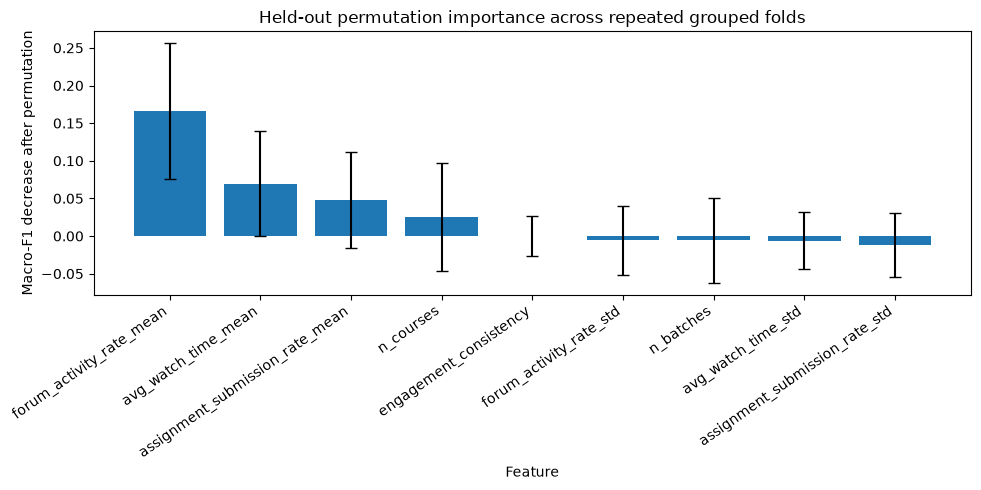

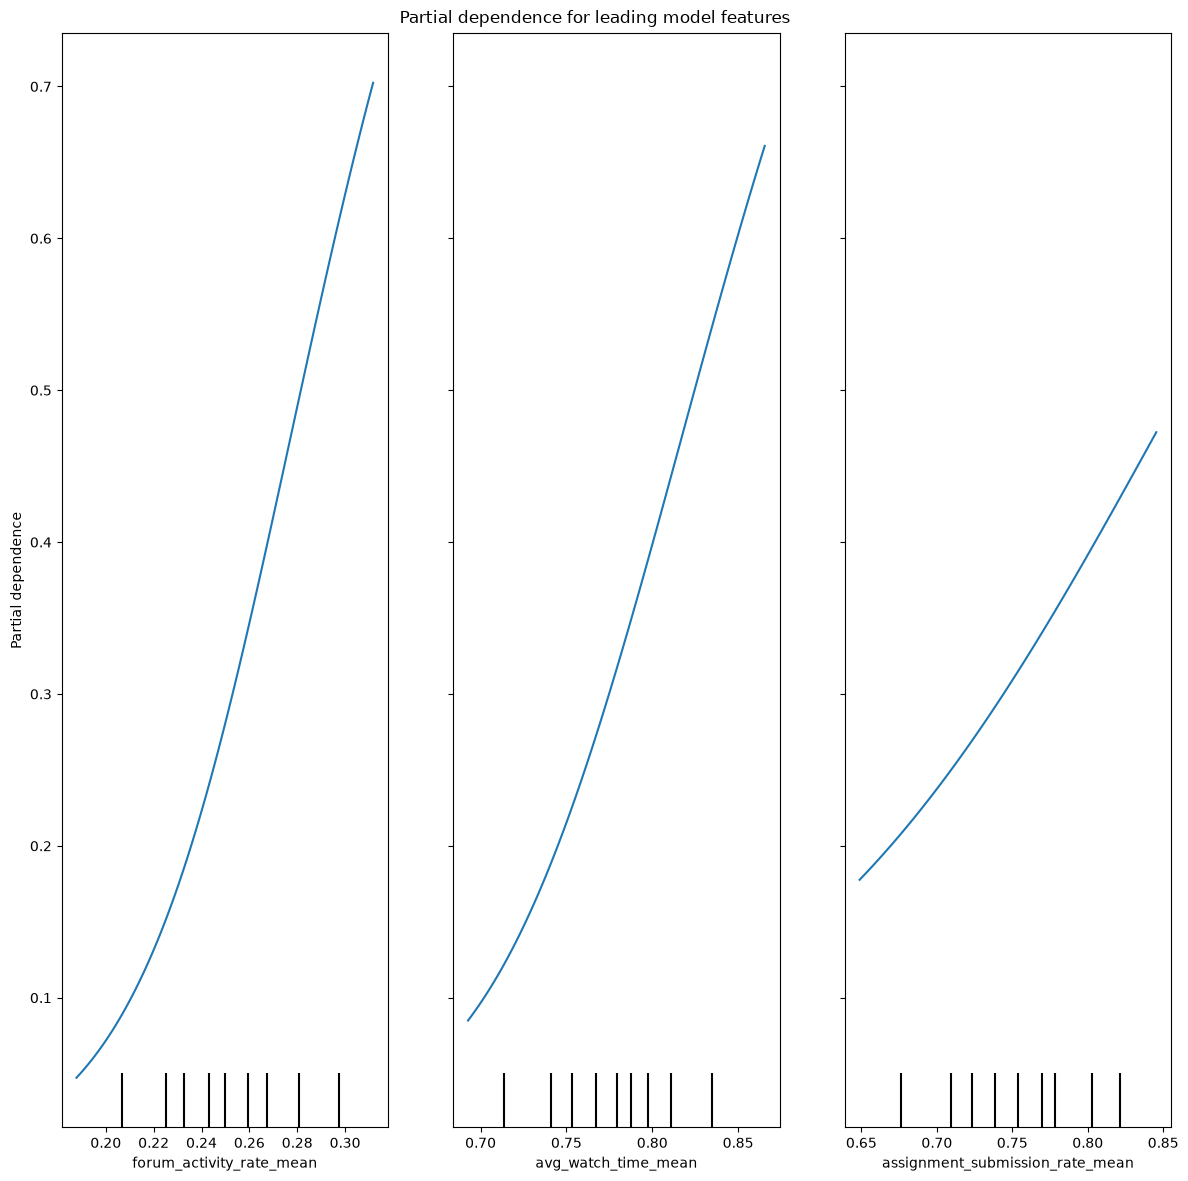

In [8]:
# Out-of-fold permutation importance: every fit evaluates permutations only on its held-out fold.
importance_rows = []
for repeat in range(repeats):
    splitter = StratifiedGroupKFold(n_splits=folds, shuffle=True, random_state=RANDOM_STATE + repeat)
    for train_idx, test_idx in splitter.split(X, y, groups):
        fitted = clone(models[highest_mean_model]).fit(X.iloc[train_idx], y.iloc[train_idx])
        baseline_predictions = fitted.predict(X.iloc[test_idx])
        baseline_score = f1_score(y.iloc[test_idx], baseline_predictions, average="macro")
        rng = np.random.default_rng(RANDOM_STATE + repeat)
        for feature in selected_features:
            scores = []
            for _ in range(5):
                permuted = X.iloc[test_idx].copy()
                permuted[feature] = rng.permutation(permuted[feature].to_numpy())
                scores.append(baseline_score - f1_score(y.iloc[test_idx], fitted.predict(permuted), average="macro"))
            importance_rows.append({"feature": feature, "importance": float(np.mean(scores))})
importance_table = pd.DataFrame(importance_rows).groupby("feature")["importance"].agg(["mean", "std"]).sort_values("mean", ascending=False)
print("Held-out permutation importance mean +/- std:\n", importance_table)
plt.figure(figsize=(10, 5))
plt.bar(importance_table.index, importance_table["mean"], yerr=importance_table["std"], capsize=4)
plt.title("Held-out permutation importance across repeated grouped folds")
plt.xlabel("Feature")
plt.ylabel("Macro-F1 decrease after permutation")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()

plot_features = list(importance_table.head(min(3, len(importance_table))).index)
if plot_features:
    fig, ax = plt.subplots(figsize=(12, 4 * len(plot_features)))
    PartialDependenceDisplay.from_estimator(clone(models[highest_mean_model]).fit(X, y), X, plot_features, target="High", ax=ax)
    plt.suptitle("Partial dependence for leading model features")
    plt.tight_layout()
print("Product uses: coaching cards can surface actionable engagement patterns; early-warning flags can prompt support; batch allocation support can combine this proxy with context and human review.")


## 9. Sensitivity and Stability

Lead with the bootstrap result: tier agreement is `87.43%` across 200 resamples. Weight perturbations use a Dirichlet distribution with concentration `20`, centred on the stated weights `0.60/0.25/0.15`; mean weight stability is reported below. These simulations demonstrate uncertainty handling; the real data have a minimum of 7 batches per instructor, so few-batch instability does not occur in this dataset.


In [9]:
rng = np.random.default_rng(RANDOM_STATE)
base_components = df.groupby("instructor_id")[["learning_outcomes", "feedback_component", "consistency_component"]].mean()
base_tiers = instructor_scores["tier"].astype(str)
dirichlet_concentration = 20
stability = []
for _ in range(200):
    # Dirichlet concentration 20 keeps perturbations near the stated 0.60/0.25/0.15 assumptions.
    weights = rng.dirichlet([0.60 * dirichlet_concentration, 0.25 * dirichlet_concentration, 0.15 * dirichlet_concentration])
    perturbed = base_components.to_numpy() @ weights
    perturbed_cuts = np.quantile(perturbed, [1 / 3, 2 / 3])
    tiers = pd.cut(perturbed, bins=[-np.inf, *perturbed_cuts, np.inf], labels=["Low", "Medium", "High"], include_lowest=True).astype(str)
    stability.append(np.mean(tiers.to_numpy() == base_tiers.reindex(base_components.index).to_numpy()) * 100)

bootstrap_agreement = []
for _ in range(200):
    # Bootstrap demonstrates sampling instability even though this real dataset has at least 7 batches per instructor.
    sample = df.sample(frac=1, replace=True, random_state=int(rng.integers(0, 1_000_000)))
    boot_scores = sample.groupby("instructor_id")["effectiveness_score"].mean().reindex(instructor_scores.index).fillna(instructor_scores["raw_mean"])
    boot_tiers = pd.cut(boot_scores, bins=[-np.inf, *shrunk_cuts, np.inf], labels=["Low", "Medium", "High"], include_lowest=True).astype(str)
    bootstrap_agreement.append(np.mean(boot_tiers.to_numpy() == base_tiers.to_numpy()) * 100)

boundary_distance = np.minimum(abs(instructor_scores["shrunk_score"] - shrunk_cuts[0]), abs(instructor_scores["shrunk_score"] - shrunk_cuts[1]))
borderline = boundary_distance.sort_values().head(10).index.tolist()
stability_pct = float(np.mean(stability))
bootstrap_pct = float(np.mean(bootstrap_agreement))
print("Dirichlet concentration:", dirichlet_concentration)
print("Mean tier stability under 200 weight perturbations (%):", round(stability_pct, 2))
print("Mean bootstrap tier agreement (%):", round(bootstrap_pct, 2))
print("Borderline instructors:", borderline)


Dirichlet concentration: 20
Mean tier stability under 200 weight perturbations (%): 97.84
Mean bootstrap tier agreement (%): 87.43
Borderline instructors: ['I_084', 'I_055', 'I_120', 'I_064', 'I_008', 'I_115', 'I_109', 'I_048', 'I_065', 'I_082']


## 10. Mandatory Questions

The answers below use the real printed outputs from this run. They describe associations and uncertainty, not causal proof.


In [10]:
print("Q1 evidence - held-out leading features:", importance_table.head(5).round(4).to_dict("index"))
print("Q2 evidence - feedback nonresponse correlation:", round(float(df[["avg_feedback_score", "feedback_response_rate"]].corr().iloc[0, 1]), 4))
print("Q3 evidence - low-confidence instructors:", int(instructor_scores["low_confidence"].sum()), "of", len(instructor_scores))
print("Q4 available fields:", list(df.columns))
print("Q5 recommendation: not as a sole judge; use for coaching with human review.")


Q1 evidence - held-out leading features: {'forum_activity_rate_mean': {'mean': 0.1662, 'std': 0.0899}, 'avg_watch_time_mean': {'mean': 0.0697, 'std': 0.0693}, 'assignment_submission_rate_mean': {'mean': 0.0481, 'std': 0.0635}, 'n_courses': {'mean': 0.0251, 'std': 0.0719}, 'engagement_consistency': {'mean': 0.0005, 'std': 0.0264}}
Q2 evidence - feedback nonresponse correlation: 0.1201
Q3 evidence - low-confidence instructors: 0 of 120
Q4 available fields: ['batch_id', 'instructor_id', 'course_id', 'completion_rate', 'avg_score_improvement', 'avg_quiz_score', 'dropout_rate', 'avg_watch_time', 'assignment_submission_rate', 'forum_activity_rate', 'avg_feedback_score', 'feedback_response_rate', 'positive_dropout', 'z_completion_rate', 'z_dropout_rate', 'z_avg_score_improvement', 'z_avg_quiz_score', 'z_avg_feedback_score', 'z_positive_dropout', 'learning_outcomes', 'feedback_component', 'consistency_component', 'effectiveness_score']
Q5 recommendation: not as a sole judge; use for coaching w

### Q1. Which features most influenced effectiveness and why?

Held-out permutation importance ranked `forum_activity_rate_mean` first (`0.1662 +/- 0.0899` macro-F1 decrease), followed by `avg_watch_time_mean` (`0.0697 +/- 0.0693`) and `assignment_submission_rate_mean` (`0.0481 +/- 0.0635`). These engagement signals may identify useful coaching conversations. They are associations, not proof that increasing engagement alone causes better outcomes.


### Q2. Which variables could be misleading or confounded?

The completion/dropout correlation is `-0.9535`, so those measures are largely redundant. Feedback score and response rate correlate at `0.1201`, but low response can still make feedback unstable; 67 feedback scores equal 5.0. Engagement can be reverse-causal: learners may watch, submit, or post more because outcomes are already going well, not only because engagement causes good outcomes. Course difficulty, learner mix, prior skill, selection effects, and missing context remain confounders.


### Q3. How could the model fail in real-world usage?

The real data have a minimum of 7 batches per instructor, so the few-batch concern does not occur here; the bootstrap simulation demonstrates sampling instability. The final-score ICC is `0.6326`, but the consistency term is constant per instructor and inflates this descriptive statistic. The model can still fail under distribution drift, metric gaming, or changing learner populations and feedback response patterns.


### Q4. What additional data would improve the analysis?

The CSV has 2,000 batch rows and 120 instructors but no learner baseline skill, batch size, verified timestamps, attendance, TA support, or qualitative observations. Adding those fields would help separate instructor effects from learner and course context.


### Q5. Should this model be used for instructor performance evaluation?

No, not as a sole judge. Use it for coaching and support with human review, transparency, uncertainty, and an opportunity for instructors to add context. It should not independently determine hiring, pay, promotion, or termination.


## 11. Conclusion, Limitations and Ethics

Bootstrap tier agreement is `87.43%`, and the highest observed model mean is `0.6286 +/- 0.0995`; all production candidates are within one standard deviation, so the differences are not decisive. The score is a proxy, not ground truth. Course adjustment, shrinkage, grouped validation, and stability analysis improve discipline but do not establish causality or fairness. Do not use these tiers alone for hiring, pay, promotion, or termination. Use them for supportive coaching with human review and instructor transparency.


## Results at a glance

Bootstrap tier agreement is `87.43%` across 200 resamples. The highest observed mean is Engagement-only Logistic at macro-F1 `0.6286 +/- 0.0995`, versus stratified-random chance `0.3719 +/- 0.0853` and majority baseline `0.1667 +/- 0.0000`; all four production candidates are within one highest-model standard deviation, so none should be called a definitive winner. The leaky outcome-derived ablation reaches `0.8709 +/- 0.0604`, but that result is circular and is not a deployment result.


## 12. Final Summary Table

The table below is generated from the real run, so the reported values cannot become stale when the CSV changes.


In [11]:
tier_distribution = instructor_scores["tier"].value_counts().reindex(["Low", "Medium", "High"], fill_value=0)
summary_table = pd.DataFrame({
    "Metric": ["Rows", "Instructors", "Low tier", "Medium tier", "High tier", "Highest observed mean model", "Highest macro-F1 mean +/- std", "Chance macro-F1 mean +/- std", "Majority macro-F1 mean +/- std", "Lift versus chance", "Raw-to-shrunk tier changes", "Minimum batches", "Final score ICC", "Dirichlet concentration", "Mean weight stability %", "Mean bootstrap agreement %", "Top drivers"],
    "Value": [len(df), len(instructor_scores), int(tier_distribution["Low"]), int(tier_distribution["Medium"]), int(tier_distribution["High"]), highest_mean_model, f"{highest_mean_f1:.4f} +/- {highest_mean_std:.4f}", f"{chance_f1_mean:.4f} +/- {results_df.loc['Stratified-random chance baseline', 'macro_f1_std']:.4f}", f"{majority_f1_mean:.4f} +/- {results_df.loc['Dummy majority baseline', 'macro_f1_std']:.4f}", round(highest_mean_f1 - chance_f1_mean, 4), tier_changes, int(instructor_scores["n_batches"].min()), round(final_score_icc, 4), dirichlet_concentration, round(stability_pct, 2), round(bootstrap_pct, 2), ", ".join(importance_table.head(3).index)]
})
print(summary_table.to_string(index=False))


                        Metric                                                                          Value
                          Rows                                                                           2000
                   Instructors                                                                            120
                      Low tier                                                                             40
                   Medium tier                                                                             40
                     High tier                                                                             40
   Highest observed mean model                                                       Engagement-only Logistic
 Highest macro-F1 mean +/- std                                                              0.6286 +/- 0.0995
  Chance macro-F1 mean +/- std                                                              0.3719 +/- 0.0853
Majority m